In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

In [39]:
import pandas as pd

data = {
    'Age': [22, 25, 28, 29, 31, 32, 35, 38, 40, 42, 45, 50],
    'Income': [25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80],
    'Buy_House': [0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1]
}

df = pd.DataFrame(data)

# Create CSV file
df.to_csv("house_purchase.csv", index=False)

print("Dataset created successfully!")
print("Shape:", df.shape)

df.head()

Dataset created successfully!
Shape: (12, 3)


,Age,Income,Buy_House
0,22,25,0
1,25,30,0
2,28,35,0
3,29,40,0
4,31,45,1


In [43]:
import pandas as pd

data = pd.read_csv("house_purchase.csv")

print(data.head())
print(data.columns)

   Age  Income  Buy_House
0   22      25          0
1   25      30          0
2   28      35          0
3   29      40          0
4   31      45          1
Index(['Age', 'Income', 'Buy_House'], dtype='object')


In [45]:
X = data[['Age', 'Income']]
y = data['Buy_House']

print("X:")
print(X)

print("\nY:")
print(y)

X:
    Age  Income
0    22      25
1    25      30
2    28      35
3    29      40
4    31      45
5    32      50
6    35      55
7    38      60
8    40      65
9    42      70
10   45      75
11   50      80

Y:
0     0
1     0
2     0
3     0
4     1
5     1
6     1
7     1
8     1
9     0
10    1
11    1
Name: Buy_House, dtype: int64


In [51]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=5
)

model.fit(X, y)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [53]:
y_pred = model.predict(X)

print("Predicted values:")
print(y_pred)

Predicted values:
[0 0 0 0 1 1 1 1 1 0 1 1]


In [55]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100)

Accuracy: 1.0
Accuracy Percentage: 100.0


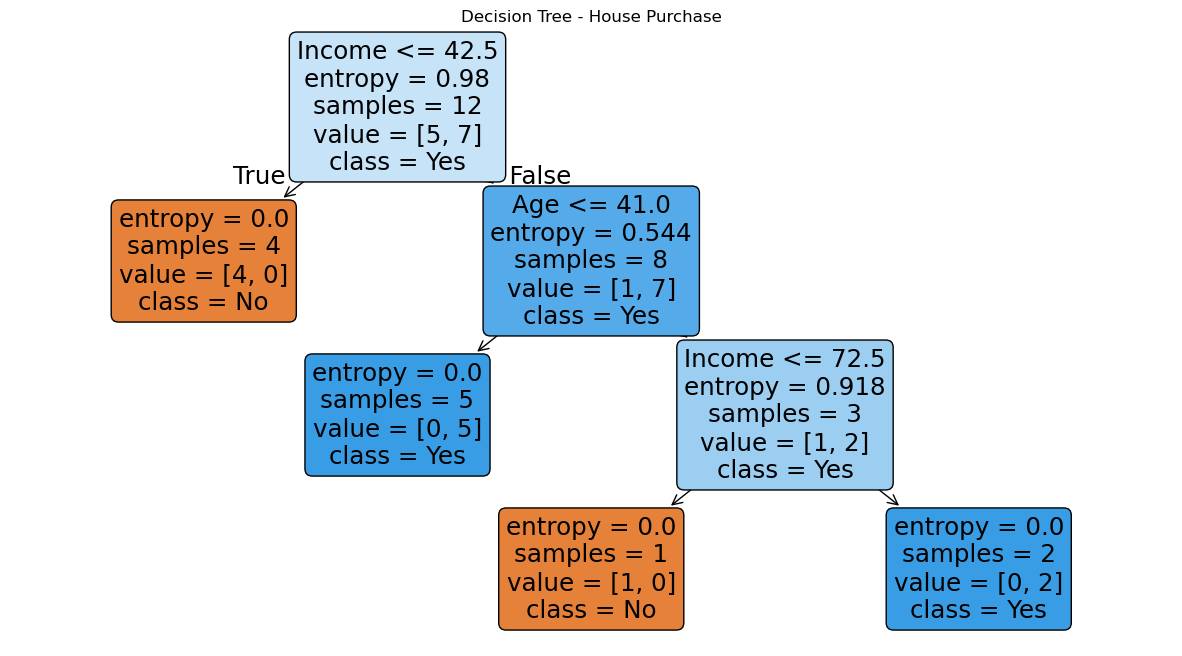

In [57]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

tree.plot_tree(
    model,
    feature_names=['Age', 'Income'],
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True
)

plt.title("Decision Tree - House Purchase")
plt.show()

In [61]:
from sklearn import metrics

# Confusion Matrix
conf_mat = metrics.confusion_matrix(y, y_pred)

print("Confusion Matrix :")
print(conf_mat)


Confusion Matrix :
[[5 0]
 [0 7]]


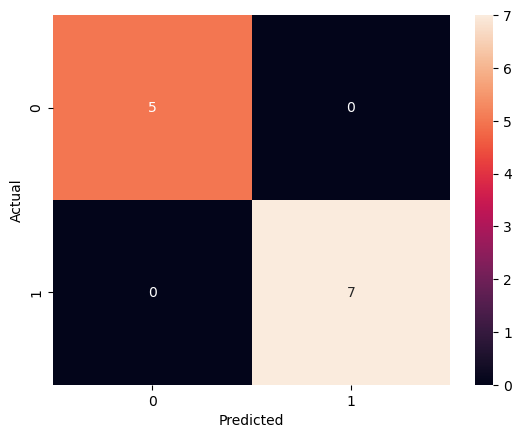

In [63]:
import seaborn as sn
import matplotlib.pyplot as plt

conf_mat = pd.crosstab(
    y,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(conf_mat, annot=True)

plt.show()